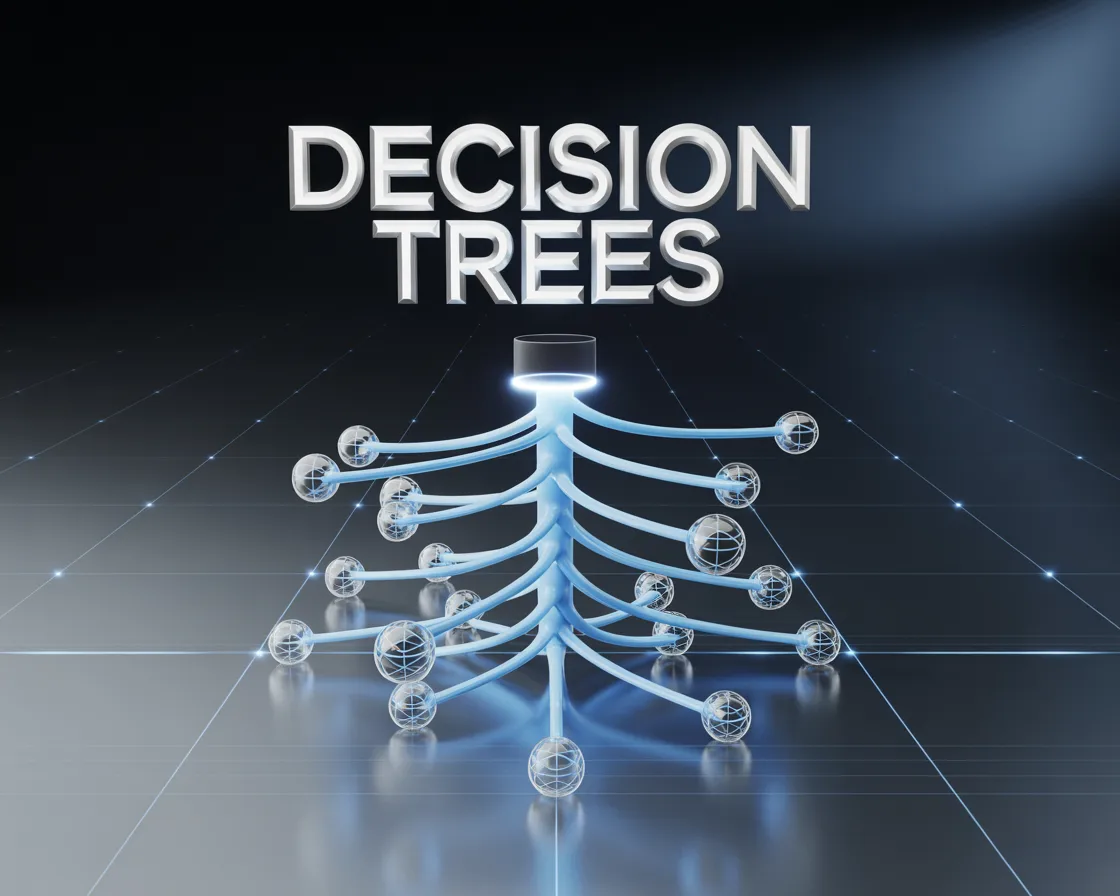

# ***Decision Trees***

### Topics Covered:
1. Decision Tree Structure
2. Splitting Criteria (Gini, Entropy)
3. Building Decision Tree in Python
4. Overfitting & Pruning
5. Feature Importance
6. Model Interpretation



### **What is a Decision Tree?**

A **Decision Tree** is a **supervised machine learning algorithm** used for:

- Classification (e.g., Spam vs Not Spam)
- Regression (e.g., Predicting house prices)

It works like a **flowchart structure**, where:
- Each **node** represents a decision
- Each **branch** represents an outcome
- Each **leaf node** represents a final prediction

---

### **How Does It Think?**

A Decision Tree mimics **human decision-making**:

It asks a series of **questions**:
- Is age > 30?
- Is income > 50K?
- Is education level high?

Based on answers, it moves step-by-step to a final decision.

---

### **Real-Life Example**

**Should you buy a laptop?**

- Budget > ₹50,000?
  - Yes → Check Brand
  - No → :Don't Buy

This step-by-step logic forms a **tree-like structure**

---

### **Key Idea**

> Decision Trees break complex decisions into **simple, interpretable rules**

---

### **Why It’s Powerful?**

- Easy to understand (even for non-technical users)
- No complex math required
- Visual and explainable model


### **Key Components of a Decision Tree**

A Decision Tree is made up of the following important parts:

---

### **1. Root Node**
- The **topmost node** of the tree  
- Represents the **entire dataset**  
- First decision is made here  

Example:  
`Is Age > 30?`

---

### **2. Decision Nodes (Internal Nodes)**
- Nodes where **conditions are applied**  
- Split the data into smaller subsets  

Example:  
`Is Income > 50K?`

---

### **3. Branches**
- Represent the **outcome of a decision**  
- Connect nodes together  

Example:  
Yes / No paths

---

### **4. Leaf Nodes (Terminal Nodes)**
- Final output of the tree  
- No further splitting happens  

**Example:**

Approve Loan  | ✅

Reject Loan   | ❌

---

### **How It Works (Flow)**

1. Start from **Root Node**  
2. Apply condition → split into branches  
3. Move to next decision node  
4. Continue until reaching a **Leaf Node**

---

### **Key Insight**
> The goal of a decision tree is to split the data in a way that each final group (leaf) is as **pure** as possible.


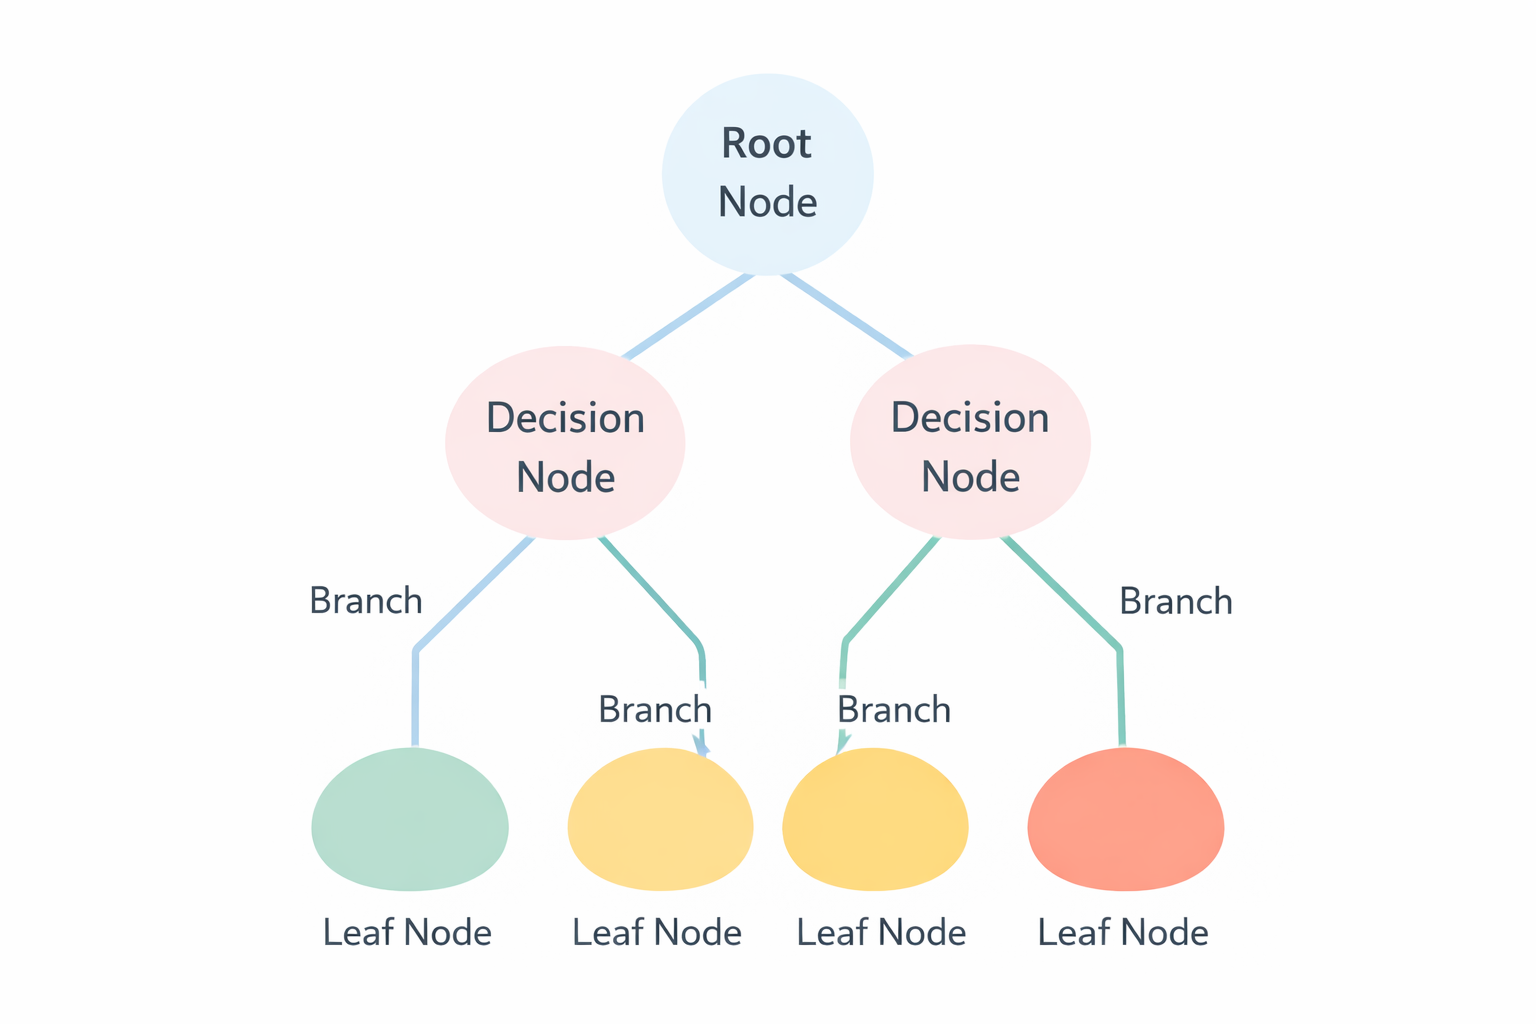

## Splitting Criteria (Gini vs Entropy)




### Why Do We Need Splitting Criteria?

A Decision Tree splits data to make better decisions.

But how does it decide **where to split?**

It uses **impurity measures** (how mixed the data is)

---

### Goal of Splitting

> Create groups that are as **pure** as possible

- Pure = Mostly one class (e.g., all “Yes”)  
- Impure = Mixed classes (Yes + No)

---

## 1. Gini Impurity

- Measures how often a randomly chosen element is **incorrectly classified**
- Lower Gini = Better split

Formula (conceptually):
Gini = 1 - (sum of squared probabilities)

---

### Intuition:
- If all values are same → Gini = 0 (Perfect)
- If mixed → Gini increases

---

## 2. Entropy

- Measures **disorder or randomness** in data
- Based on **logarithmic calculation**

Formula:
Entropy = - Σ (p × log₂ p)

---

### Intuition:
- Pure data → Entropy = 0  
- Highly mixed → Entropy = High  

---

## Gini vs Entropy

| Criteria | Gini | Entropy |
|----------|------|---------|
| Speed | Faster  | Slower |
| Complexity | Simple | Complex |
| Default | Yes (sklearn) | Optional |
| Interpretation | Easier | More theoretical |


---

### Interview Tip

If asked:
**“Which is better?”**

✔ Answer:
- Gini is preferred for speed  
- Entropy is used when deeper information gain analysis is needed  


## Dataset Introduction (Adult Census Income)


[Adult Dataset:](https://drive.google.com/file/d/15l6j2GdJNJfAKhhLhB1Kam-r06cLoeAX/view?usp=sharing)


We will use a **real-world dataset** to build our Decision Tree model.



---

### About the Dataset

- **30,000+ rows (large dataset)**  
- Multiple features (columns)  
- Target Variable: Income  

---

### Key Features (Columns)

- Age  
- Workclass  
- Education  
- Occupation  
- Marital Status  
- Hours per week  
- Capital Gain / Loss  
- Native Country  

---

### Target Variable

 `income`

- `<=50K` → Low income  
- `>50K` → High income  

---

### Problem Statement

> Build a model to predict whether a person's income is **>50K or <=50K**

---

### What We Will Do Next

1. Load dataset  
2. Perform data cleaning  
3. Convert categorical data  
4. Train Decision Tree model  


## Import Libraries & Setup



### Step 1: Import Required Libraries

Before building our model, we need to import necessary Python libraries.

---

### Libraries We Will Use

- **Pandas** → Data manipulation  
- **NumPy** → Numerical operations  
- **Matplotlib** → Visualization  
- **Scikit-learn** → Machine Learning  

---

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree

### Step 2: Load the Dataset

Now we will load the dataset into Python using Pandas.

---

### Upload Dataset in Colab

Option 1: Upload manually
```python
from google.colab import files
uploaded = files.upload()

In [ ]:
# Option 2: Use file path
df = pd.read_csv('/content/adult.csv')

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape   # Rows & Columns
df.columns # Column names

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


### Step 3: Explore the Dataset

Before building a model, we must **understand the data properly**.

---

### Check Data Types & Structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


### Step 4: Clean the Dataset

Before training the model, we must handle **missing or incorrect values**.

---

### Problem in Dataset

- Missing values are stored as `"?"`  
- Python does NOT recognize `"?"` as missing  

---

### Step 1: Replace "?" with NaN

```python id="r9k1p2"
df.replace('?', np.nan, inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


### Step 5: Convert Categorical Data → Numerical

Machine Learning models **cannot understand text (categorical data)** directly.

We need to convert it into numbers.

---

### What is Categorical Data?

Columns like:
- Workclass  
- Education  
- Occupation  
- Marital Status  

These contain text values → must be encoded

---

### Solution: One-Hot Encoding

- Converts categories into **binary columns (0/1)**
- Each unique value becomes a new column

---

In [ ]:
### Code
df = pd.get_dummies(df, drop_first=True)

## ⚠️ Important: Target Variable Encoding

After encoding, check:

df.columns

Target column becomes:
'income_>50K'

✔ 1 → >50K  
✔ 0 → <=50K

###  Step 6: Define Features and Target

Now we separate our dataset into:

- **X (Features / Independent Variables)**  
- **y (Target / Dependent Variable)**  

---

### What is Target Variable?

The column we want to predict  

In our case:  
`income_>50K`

- 1 → Income > 50K  
- 0 → Income <= 50K  

---

### What are Features?

👉 All remaining columns used to make predictions  

Examples:
- Age  
- Education  
- Hours per week  
- Occupation  

---

In [ ]:
# Features (Input)
X = df.drop('income_>50K', axis=1)

# Target (Output)
y = df['income_>50K']

In [ ]:
y.value_counts()

,count
income_>50K,
False,24720
True,7841


## Interpretation: Class Distribution

- If one class has much higher count → dataset is imbalanced  
- Example:
  - 75% <=50K
  - 25% >50K  

⚠️ Accuracy can be misleading in such cases

Need to focus on Precision & Recall


### Step 7: Split Data into Training & Testing

Before training the model, we divide the dataset into:

- 🟦 **Training Data** → Used to train the model  
- 🟩 **Testing Data** → Used to evaluate the model  

---

### Why Do We Split Data?

To check how well the model performs on **unseen data**

> If we test on training data → results will be misleading   

---

### Common Split Ratio

- 80% → Training  
- 20% → Testing  

---


In [ ]:
### Code

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Step 8: Train the Decision Tree Model

Now we build our **Decision Tree Classifier** using training data.

---


In [ ]:

# Create model
model = DecisionTreeClassifier(
    criterion='gini',   # Splitting criteria
    max_depth=5         # Control tree depth
)

# Train model
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

### 🚀 Step 9: Generate Predictions

Now that our model is trained, we use it to make predictions on **test data**.

---


In [ ]:
### 💻 Code

y_pred = model.predict(X_test)


### Step 10: Evaluate Model Performance

Now we check how well our model is performing.

---



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[4747,  229],
       [ 745,  792]])

## Confusion Matrix Interpretation

|                | Predicted 0 | Predicted 1 |
|----------------|------------|-------------|
| Actual 0       | TN         | FP          |
| Actual 1       | FN         | TP          |

- TP → Correctly predicted high income  
- TN → Correctly predicted low income  
- FP → Wrongly predicted high income  
- FN → Missed high income  

Business impact:
- FP → Wrong targeting  
- FN → Missed opportunity

In [ ]:
### Code

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8504529402732995
              precision    recall  f1-score   support

       False       0.86      0.95      0.91      4976
        True       0.78      0.52      0.62      1537

    accuracy                           0.85      6513
   macro avg       0.82      0.73      0.76      6513
weighted avg       0.84      0.85      0.84      6513



In [ ]:
train_pred = model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

Training Accuracy: 0.852080773955774
Testing Accuracy: 0.8504529402732995


## Interpretation: Overfitting Check

- If Training Accuracy >> Testing Accuracy  
  → Model is overfitting  

- If both are similar  
  → Model is good  

Example:
Train = 95%  
Test = 80%  
⚠️ Overfitting detected




### Step 11: Visualize the Decision Tree

Visualization helps us **understand how the model makes decisions**.

---



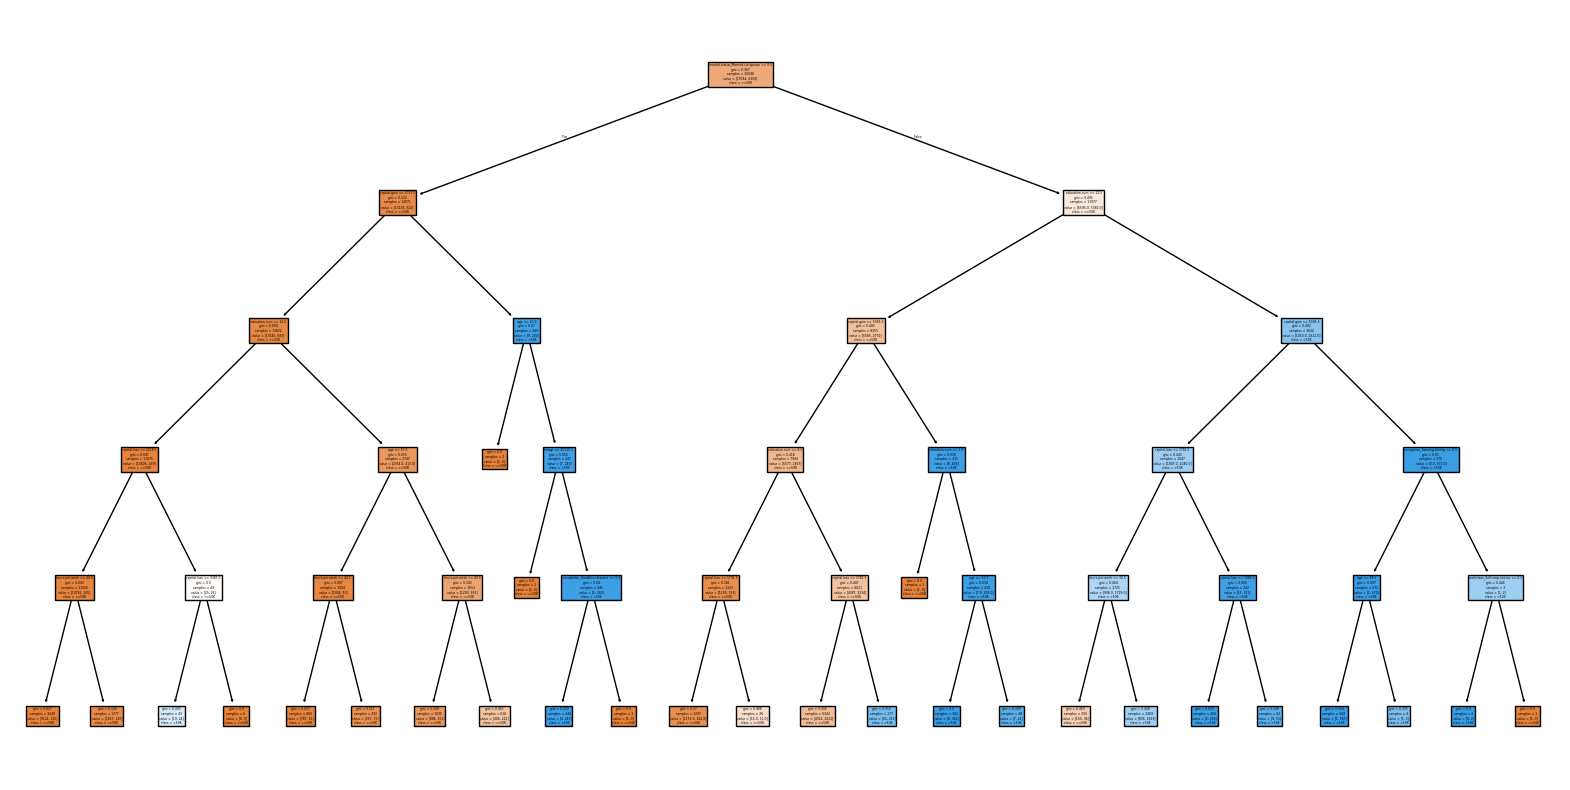

In [ ]:
### Code

plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['<=50K', '>50K']
)

plt.show()

### What is Overfitting?

Overfitting happens when a model:

* Learns **training data too well**  
* Including noise and unnecessary patterns  

---

### Problem

- Performs very well on training data   
- Performs poorly on new (test) data  

---

### Overfitting in Decision Trees

- Tree becomes **too deep**  
- Creates too many branches  
- Memorizes data instead of learning patterns  

---

### Signs of Overfitting

- Very high training accuracy  
- Low testing accuracy  
- Complex tree structure  

---

### Real-Life Analogy

> Like memorizing answers instead of understanding concepts

---

### Underfitting vs Overfitting

| Type | Description |
|------|------------|
| Underfitting | Model too simple |
| Overfitting | Model too complex |
| Good Fit | Balanced model |

---

### Key Insight

> Goal is to find the **right balance** between simplicity and accuracy

---



### What is Pruning?

Pruning means **reducing the size of the decision tree**  
Remove unnecessary branches  

---

### Why Pruning?

- Prevent overfitting  
- Improve model generalization  
- Make tree simpler and interpretable  

---

### Types of Pruning (Concept)

1. **Pre-Pruning (Early Stopping)**  
   - Stop tree growth early  

2. **Post-Pruning**  
   - Build full tree → then remove branches  

---

### Common Parameters (Pre-Pruning)

- `max_depth` → Limits tree depth  
- `min_samples_split` → Minimum samples to split  
- `min_samples_leaf` → Minimum samples in leaf  

---

In [ ]:
### Code Example


model_pruned = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10
)

model_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20)

In [ ]:
y_pred_pruned = model_pruned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_pruned))

Accuracy: 0.8447719944725933


In [ ]:
for depth in [3, 5, 10]:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Depth: {depth}, Accuracy: {accuracy_score(y_test, y_pred)}")

Depth: 3, Accuracy: 0.8447719944725933
Depth: 5, Accuracy: 0.8506064793489944
Depth: 10, Accuracy: 0.8522954091816367


## Interpretation: Depth vs Accuracy

- Small depth → Underfitting  
- Large depth → Overfitting  
- Optimal depth → Best balance  

Goal = Find sweet spot



### What is Feature Importance?

Feature Importance tells us:

**Which features are most important for making predictions**

---

###  Why is it Important?

- Helps understand model decisions  
- Useful for business insights  
- Helps in feature selection  

---


In [ ]:
### Code

importances = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
30,marital.status_Married-civ-spouse,0.381610
2,education.num,0.202805
3,capital.gain,0.181705
4,capital.loss,0.066504
0,age,0.050866
5,hours.per.week,0.033577
38,occupation_Exec-managerial,0.015014
1,fnlwgt,0.014029
44,occupation_Prof-specialty,0.007907
11,workclass_Self-emp-not-inc,0.005857


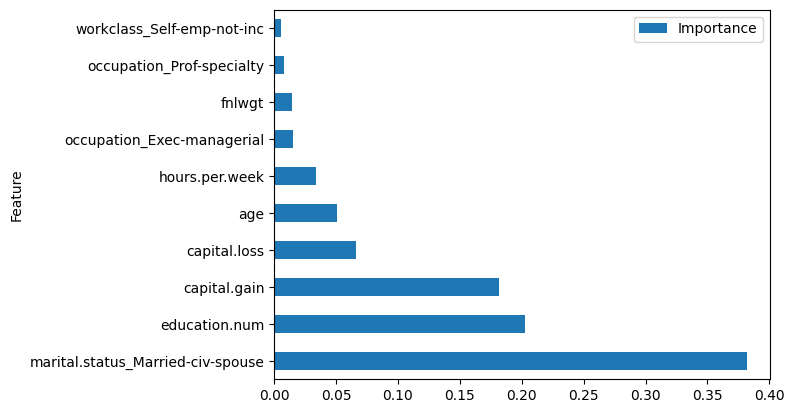

In [ ]:
feature_importance.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.show()

##Interpretation: Feature Importance Graph

- Top features drive model decisions  
- Low importance features can be removed  

Helps in:
- Feature selection  
- Model simplification


### Turning Model Output into Insights

* Building a model is not the final goal

* The real goal is to **extract meaningful insights**

---

### Key Observations from Model

- Certain features strongly influence predictions  
- Model identifies patterns in income levels  
- Helps classify individuals into income groups  

---

### Example Insights

People with:
- Higher education  
- More working hours  
- Specific occupations  

➡ More likely to earn **>50K**

---



### Business Use Cases

- 💰 **Finance** → Loan approval decisions  
- 📢 **Marketing** → Target high-income customers  
- 🏥 **Healthcare** → Risk prediction  
- 🛒 **Retail** → Customer segmentation  

---

### Key Takeaway

> Machine Learning is not just prediction — it's about **decision-making support**

---

### ⚠️ Important Note

- Model predictions should support decisions, not replace human judgment  
- Always validate with domain knowledge  

---




### Interative Questions
- What insights can you derive from your model?
- How can a company use these predictions?

---

### What We Learned

- Decision Tree Fundamentals  
- Gini vs Entropy  
- Data Cleaning & Preprocessing  
- Model Building & Evaluation  
- Overfitting & Pruning  
- Feature Importance & Insights  

---

### Key Takeaway

> “A good model is not just about accuracy, but about **understanding and decision-making**”

---

### Keep Practicing!

- Try different datasets  
- Experiment with parameters  
- Build your own ML projects  

---

### Questions?

Feel free to ask and explore more!

---

### **Thank You & Happy Learning!**
